In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [ ]:
data = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'], 
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]


data.sort(key=lambda x: np.random.random()) #random shuffle
data_train, data_validation = data[:6], data[6:] #train-validation split 75-25


In [ ]:
X=[row[0:3] for row in data]
X=np.array(X)
X_train=(X-X.mean(axis=0))/X.std(axis=0)#normalise x
Y=[row[3] for row in data]

OHE_map={"Apple":0,"Banana":1,"Orange":2}#One Hot Encode Y
Y_train=np.zeros((len(Y),len(OHE_map)))
Y_train_le=np.array([OHE_map[item] for item in Y])#to check results
for i,item in enumerate(Y):
    print(i,OHE_map[item])
    Y_train[i,OHE_map[item]]=1

print(Y_train)
# could vectorise and make preprocessing more efficient but useless for small dataset

0 0
1 2
2 2
3 1
4 0
5 1
6 1
7 0
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


In [ ]:
X_val=[row[0:3] for row in data_validation]
X_val=np.array(X_val)
X_val=(X_val-X.mean(axis=0))/X.std(axis=0)

Y_val=[row[3] for row in data_validation]
Y_val=np.array([OHE_map[item] for item in Y_val])
#preprocess validation data

In [ ]:
def Euclidian_distance(x1,x2):
    return np.linalg.norm(x1-x2)
#vectorised version of Euclidian distance for efficiency
def EDV(X,x2):
    return np.linalg.norm(X-x2,axis=1)

#Manhattan distance is the sum of absolute differences between two points. (L1 norm)
def Manhattan_distance(x1,x2):
    return np.linalg.norm(x1-x2,ord=1)
def MDV(X,x2):
    return np.linalg.norm(X-x2,axis=1,ord=1)

#Minkowski distance is a generalization of both Euclidean and Manhattan distances. (L_p norm)
def Minkowski_distance(x1,x2,p):
    return np.linalg.norm(x1-x2,ord=p)
def MKDV(X,x2,p=3):
    return np.linalg.norm(X-x2,axis=1,ord=p)

#Chebyshev distance is the maximum absolute difference between two points. (L_inf norm)
def Chebyshev_distance(x1,x2):
    return np.linalg.norm(x1-x2,ord=np.inf)
def CDV(X,x2):
    return np.linalg.norm(X-x2,axis=1,ord=np.inf)


class KNN:
    def __init__(self,n=3,dist="Euclidian",weight=None):
        self.N=n
        self.X=None
        self.Y=None
        self.weight=weight


        if(dist=="Euclidian"):
            self.dist_func=EDV
        elif(dist=="Manhattan"):
            self.dist_func=MDV
        elif(dist=="Minkowski"):
            self.dist_func=MKDV
        elif(dist=="Chebyshev"):
            self.dist_func=CDV
        else:
            raise NotImplementedError("Given distance function is not implemented")
       
    def fit(self,X,Y):
        self.X=X
        self.Y=Y

    def predict_probs(self,X):
        y_pred=np.zeros((len(X),self.Y.shape[1]))
        for i in range(len(X)):
            #compute distances from X[i] to all points in training set
            distances=self.dist_func(self.X,X[i])
            #get indices of N nearest neighbours
            top5_index=np.argsort(distances)[:self.N]
            voters=self.Y[top5_index]
            vot_d=distances[top5_index]

            if(self.weight=="1/d"):
                voters=voters/vot_d
            elif(self.weight=="1/d2"):
                voters=voters/(vot_d**2)
            #1/d and 1/d^2 weights

            elif (type(self.weight) is np.ndarray):
                voters=self.weight[top5_index]*voters
            #assigned weights by the user. This is useful when there are class imbalances,
            # or you have more confidence in some of your data compared to the rest
    

            y_pred[i]=voters.mean(axis=0)
            #taking mean since y is OHEed, could also do majority voting by taking argmax of sum of voters instead of mean
        return y_pred
    def predict(self,X):
        return np.argmax(self.predict_probs(X),axis=1)
        #taking argmax to get the class with highest probability
    def predict_one(self,X):
        return np.argmax(self.predict_probs(X),axis=1)



solver=KNN()
solver.fit(X_train,Y_train)




In [66]:
def accuracy(y_true,y_pred):
    return np.mean(y_true==y_pred)

print("Accuracy:",accuracy(Y_val,solver.predict(X_val)))

Accuracy: 1.0


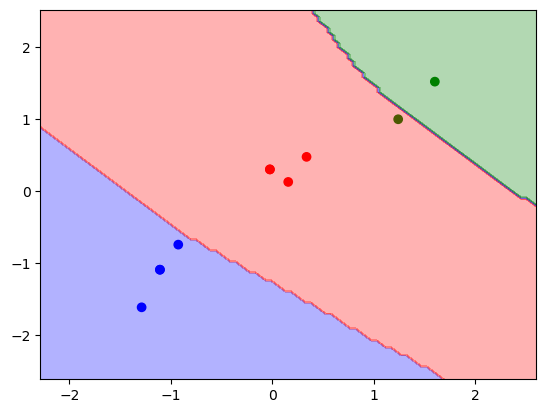

In [ ]:
#PLOTTING  APPROXIMATE DECISION BOUNDARIES


plt.scatter(X_val[:, 0], X_val[:, 1], c=ListedColormap(['red', 'blue', 'green'])(Y_val))
plt.scatter(X_train[:, 0], X_train[:, 1], c=ListedColormap(['red', 'blue', 'green'])(Y_train_le))
#plotting training and validation data in the 2D space of the first two features, colored by their class labels

# Create mesh for features 0 and 1, fix feature 2 to mean
#matplotlib doesn't support 3D decision boundaries, 
# so we fix the third (non-continous) feature to its mean value and plot the decision boundary in the 2D space of the first two features.
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
fixed_z = X_train[:, 2].mean()  # Fix third feature to mean
mesh_points = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, fixed_z)]
preds = solver.predict(mesh_points)
plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.3, cmap=ListedColormap(['red', 'blue', 'green']))


'''
Note that the actual decision boundary in 3D space would be more complex, but this gives an approximate visualization of the decision regions in the 2D space of the first two features.
(The one green point that is within the red region is not misclassified, in the decision boundary in the 3D space of all features, it will be inside the green region).
'''


plt.plot()
plt.show()

In [ ]:
test_data = np.array([
    [118, 6.2, 0],  # Expected: Banana
    [160, 7.3, 1],  # Expected: Apple
    [185, 7.7, 2]   # Expected: Orange
])



X_test=[row[0:3] for row in test_data]
X_test=np.array(X_test)
X_test=(X_test-X.mean(axis=0))/X.std(axis=0)


result=solver.predict(X_test)
print(result)# Raw classes
decode={0:"Apple",1:"Banana",2:"Orange"}


print([decode[i] for i in result])

# The predicted classes for the test data points, decoded back to their original labels. The model predicts everything correctly in this case.

[1 0 2]
['Banana', 'Apple', 'Orange']
